In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data["price"] = housing.target

In [11]:
x = data[['AveRooms']]
y = data['price'].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [14]:
w = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(x_train_scaled)

In [15]:
for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b
    dw = (1 / n) * np.sum((y_pred - y_train) * x_train_scaled.flatten())
    db = (1 / n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        cost = (1 / (2 * n)) * np.sum((y_pred - y_train) ** 2)
        print(f"Epoch {i}, Cost {cost:.4f}")


Epoch 0, Cost 2.8149
Epoch 100, Cost 0.9414
Epoch 200, Cost 0.6904
Epoch 300, Cost 0.6568
Epoch 400, Cost 0.6523
Epoch 500, Cost 0.6517
Epoch 600, Cost 0.6516
Epoch 700, Cost 0.6516
Epoch 800, Cost 0.6516
Epoch 900, Cost 0.6516


In [16]:
y_pred_gd = w * x_test_scaled.flatten() + b

In [17]:
print("\nGradient Descent:")
print("----------------")
print("Weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R2 Score:", r2_score(y_test, y_pred_gd))


Gradient Descent:
----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


In [19]:
X_train_ne = np.c_[np.ones((len(X_train),1)), X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)), X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta

In [36]:
index=0
for i in theta:
    print (f"Theta {index}: ",i)
    index+=1

Theta 0:  1.6547622685968417
Theta 1:  0.07675558963126736


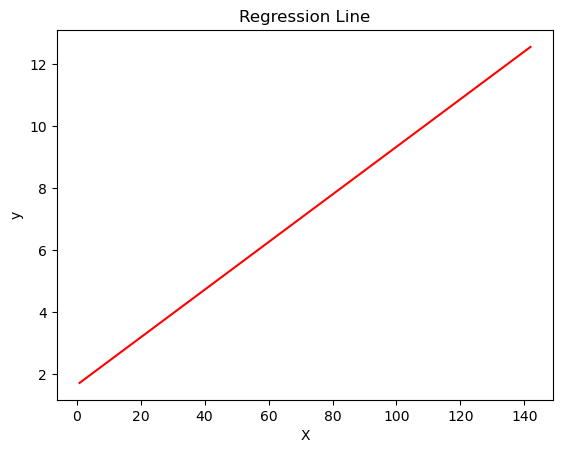

In [41]:
x = np.linspace(X_train.min(), X_train.max(), 100)
y = theta[0] + theta[1] * x

plt.plot(x, y, color='red')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Line")
plt.show()

In [44]:
print(X_train)

       AveRooms
14196  5.017657
8267   4.473545
17445  5.645833
14265  4.002817
2271   6.268421
...         ...
11284  6.129032
11964  6.868597
5390   3.986717
860    6.395349
15795  3.402576

[16512 rows x 1 columns]
